In [2]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import sys


In [3]:
df_mnkc = pd.read_csv("/data/rd_exchange/asauvebois/dataset_global/df_micronekton_old.csv", index_col='date', parse_dates= True)


In [4]:
biomass_selected = "mnkc_hmlmeso"
biome_selected = [1.0, 5.0,2.0, 4.0, 3.0]
sliced_biome = [2.0, 3.0, 4.0]


Province 101.0 : 4 NaN sur 326 valeurs
Province 102.0 : 4 NaN sur 326 valeurs
Province 103.0 : 4 NaN sur 326 valeurs
Province 501.0 : 4 NaN sur 326 valeurs
Province 502.0 : 4 NaN sur 326 valeurs
Province 503.0 : 4 NaN sur 326 valeurs
Province 201.0 : 4 NaN sur 326 valeurs
Province 202.0 : 4 NaN sur 326 valeurs
Province 203.0 : 4 NaN sur 326 valeurs
Province 204.0 : 4 NaN sur 326 valeurs
Province 205.0 : 4 NaN sur 326 valeurs
Province 401.0 : 4 NaN sur 326 valeurs
Province 402.0 : 4 NaN sur 326 valeurs
Province 403.0 : 4 NaN sur 326 valeurs
Province 404.0 : 4 NaN sur 326 valeurs
Province 405.0 : 4 NaN sur 326 valeurs
Province 406.0 : 4 NaN sur 326 valeurs
Province 301.0 : 4 NaN sur 326 valeurs
Province 302.0 : 4 NaN sur 326 valeurs
Province 303.0 : 9 NaN sur 323 valeurs
Province 304.0 : 4 NaN sur 326 valeurs
Province 305.0 : 4 NaN sur 326 valeurs
Province 306.0 : 4 NaN sur 326 valeurs
Province 307.0 : 4 NaN sur 326 valeurs


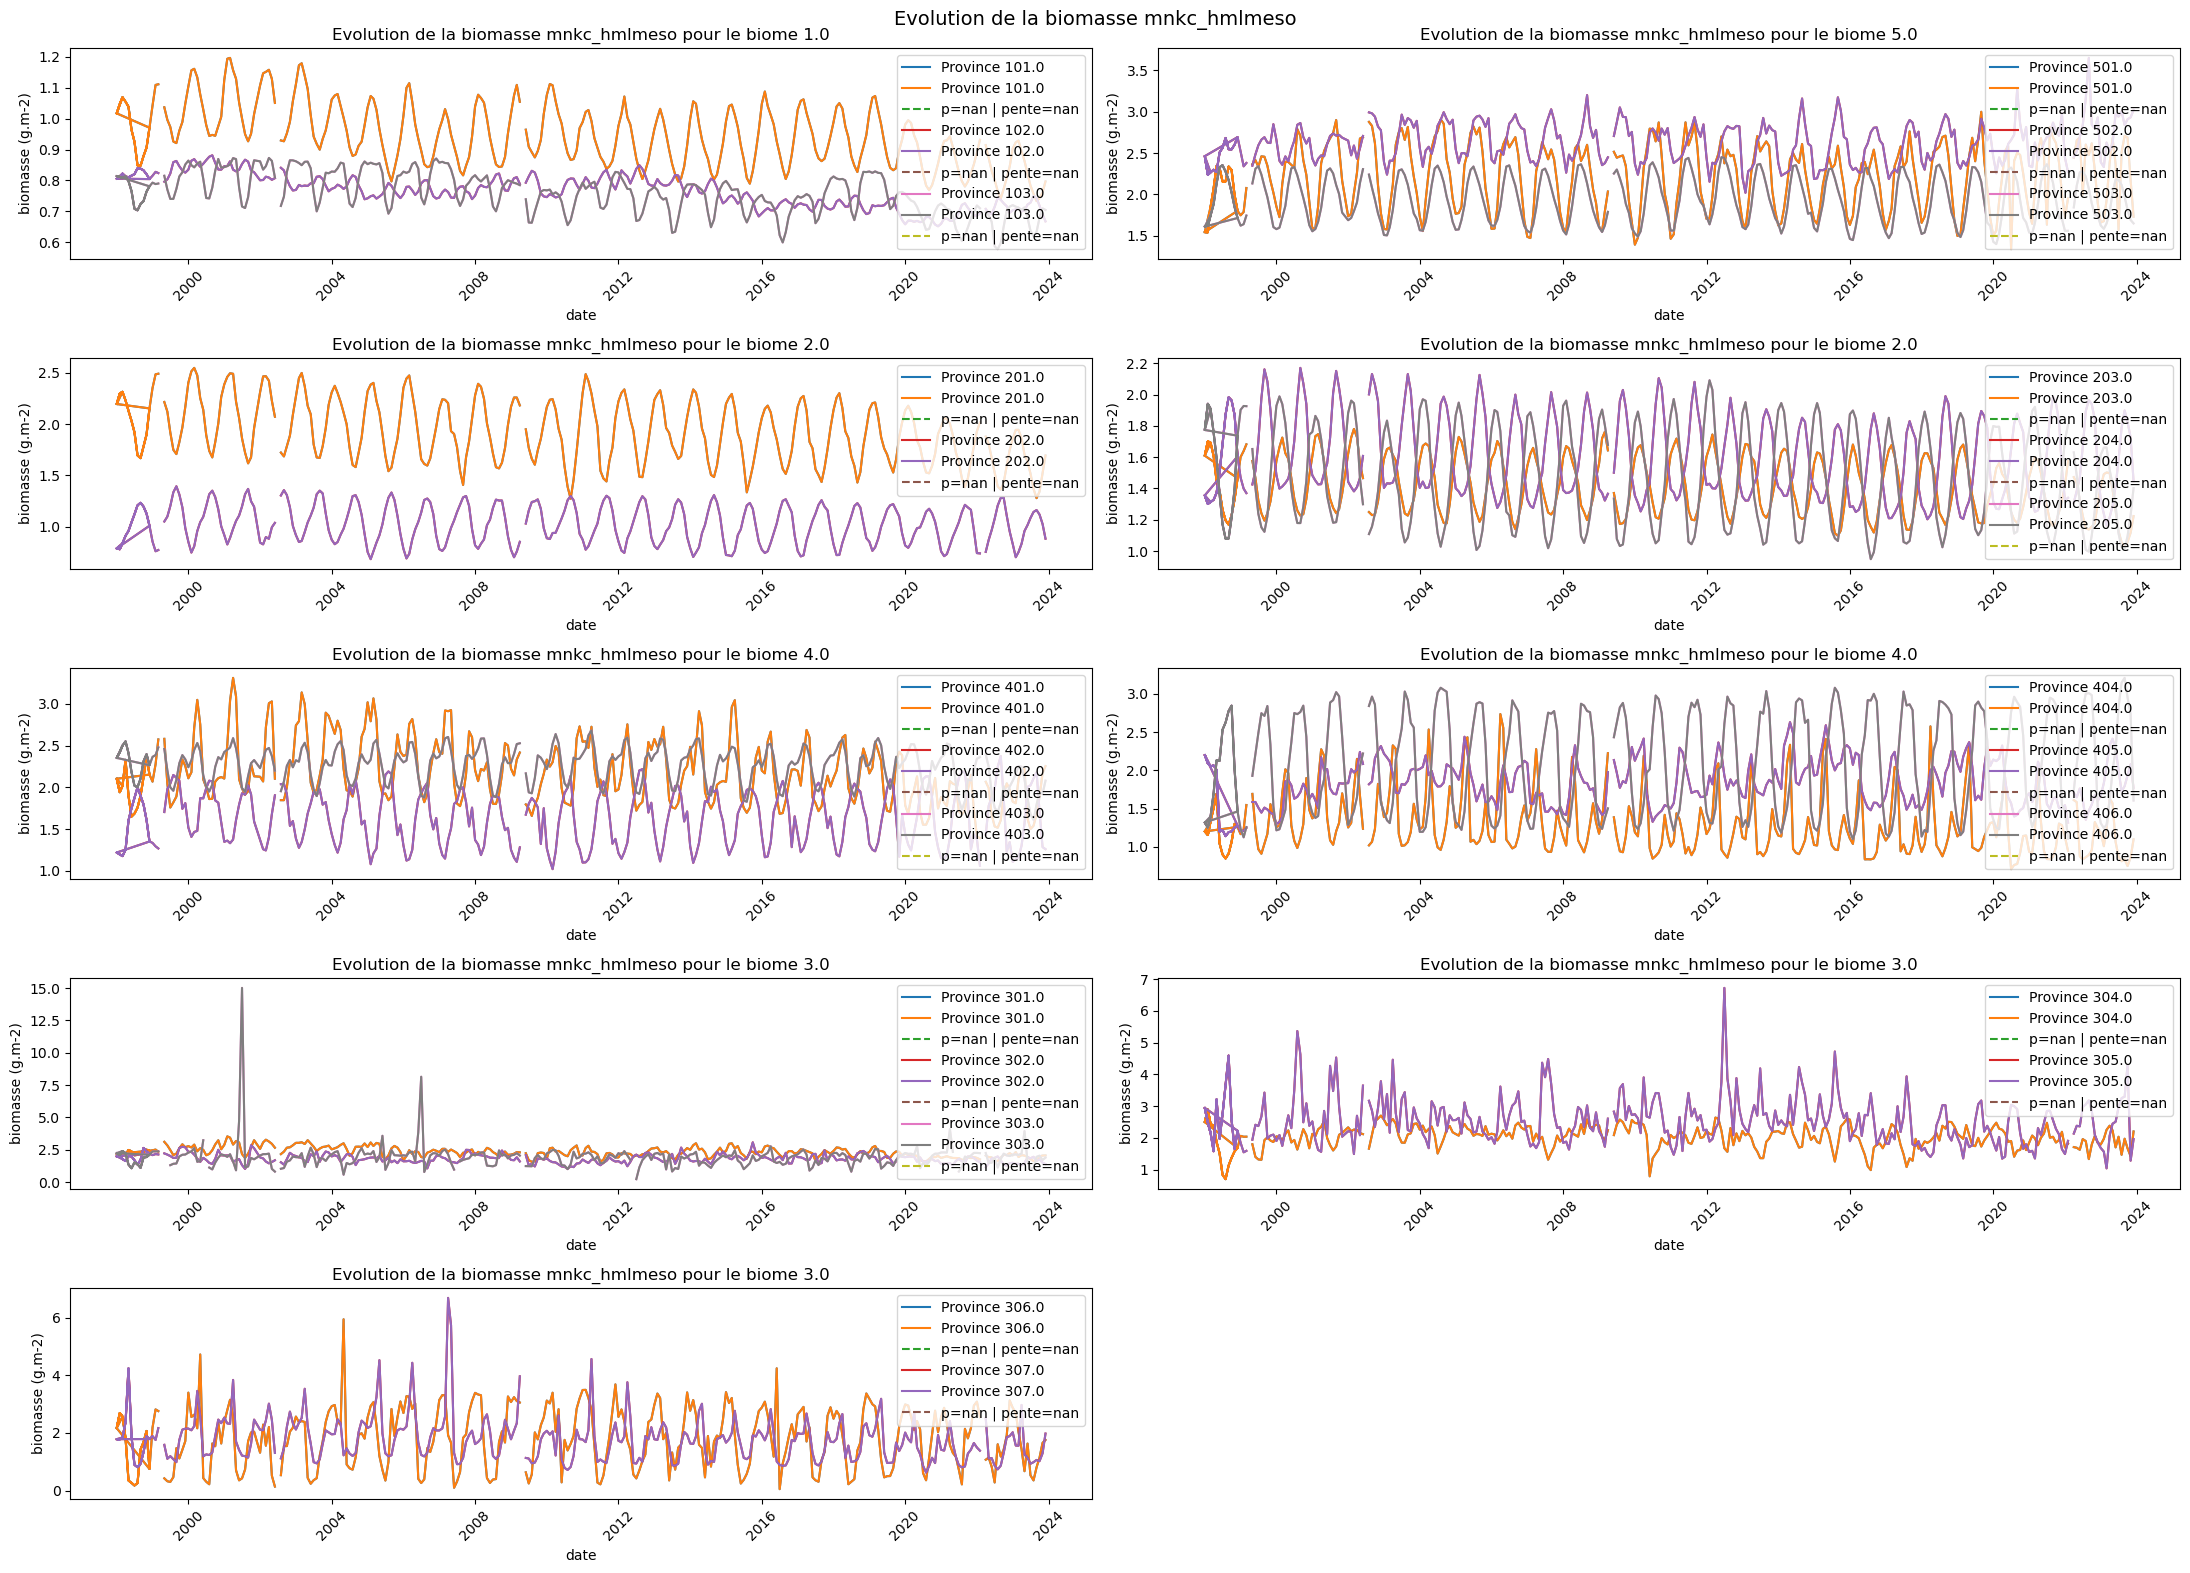

In [8]:
plt.figure(figsize=(22, 16))

subplot_idx = 1


for biome in biome_selected:
    df_by_biome= df_mnkc[df_mnkc["Biome"] == biome]
    provinces= list(df_by_biome["prov"].unique())

    if len(provinces) <=3:
        groups = [provinces]
    elif len(provinces) <= 6:
        middle = len(provinces) // 2
        groups = [provinces[:middle], provinces[middle:]]
    else:  # 7 provinces → 3 groupes de 3, 2, 2
        groups = [provinces[:3], provinces[3:5], provinces[5:]]
    

    for group in groups:
        plt.subplot(5, 2, subplot_idx)

        for prov_id in group:
            df_prov= df_by_biome[df_by_biome['prov'] == prov_id]
            plt.plot(df_prov.index, df_prov[biomass_selected], label=f"Province {prov_id}")

            y = df_prov[biomass_selected].values
            x = np.arange(len(y))

            # Supprimer les NaN
            mask_nan = ~np.isnan(y)
            x_clean = x[mask_nan]
            y_clean = y[mask_nan]


            print(f"Province {prov_id} : {df_prov[biomass_selected].isna().sum()} NaN sur {len(df_prov)} valeurs")

            slope, intercept, r, pvalue, se = stats.linregress(x, y)

            plt.plot(df_prov.index, y , label=f"Province {prov_id}")

            plt.plot(df_prov.index, intercept + slope * x,
                     linestyle='--',
                     label=f"p={pvalue:.3f} | pente={slope:.4f}")
            
        plt.title(f"Evolution de la biomasse {biomass_selected} pour le biome {biome}")
        plt.xlabel("date")
        plt.ylabel("biomasse (g.m-2)")
        plt.legend()
        plt.xticks(rotation=45)

        subplot_idx +=1

plt.suptitle(f"Evolution de la biomasse {biomass_selected}", fontsize=14)
plt.tight_layout()
plt.show()

